In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.io import savemat
import math
from common.loading_real_wave_noise import loading_real_wave_noise
from common.Reading_path_test import loading_paths_from_MAT
from gfanc.Control_filter_selection_pre_now import Control_filter_selection_pre_now
from gfanc.Control_filter_selection import Control_filter_selection
from gfanc.Fixed_filter_noise_cancellation_subfilters import Fixed_filter_controller
from data.Disturbance_generation import Disturbance_generation_from_real_noise
from fxlms.FxLMS_algorithm_v2 import FxLMS, train_fxlms_algorithm

print(torch.cuda.is_available())

True


In [ ]:
def sound_pressure_level_smoothed(dis, error, time=0.125, fs=16000):
    dis = np.array(dis)
    error = np.array(error)

    power_ratio = (dis**2) / (error**2)
    window_size = int(time * fs)
    window = np.ones(window_size) / window_size
    smoothed_power_ratio = np.convolve(power_ratio, window, mode='same')
    # print(np.mean(dis**2), np.mean(error**2))
    return 10 * np.log10(smoothed_power_ratio)

In [3]:
# plt.rc('font', size=18, family='Times New Roman') # 将plt画图时字号设置为9字体设置为Times New Roman
plt.rc('axes', titlesize=18) # fontsize of the axes title
plt.rc('axes', labelsize=18) # fontsize of the x and y labels
plt.rc('xtick', labelsize=18) # fontsize of the tick labels
plt.rc('ytick', labelsize=18) # fontsize of the tick labels
plt.rc('legend', fontsize=15) # legend fontsize
plt.rc('figure', titlesize=18) # fontsize of the figure title

In [4]:
def sound_pressure_level(dis, error, fs=16000):

    dis = np.array(dis)
    error = np.array(error)
    
    power_ratio = np.mean(dis**2) / np.mean(error**2)

    return 10 * np.log10(power_ratio)

In [42]:
import os 
# files = os.listdir("Dis Noise From Real Noise/20250506_音データ")
# for file in files:
#     print(file[:-len(".wav")])
files = ["Aircraft", "Helicopter", "Traffic"]
files = files[1:]

In [6]:
# import librosa
# import librosa.display
# import matplotlib.pyplot as plt
# import os
# base_dir = "Dis Noise From Real Noise/20250506_音データ"
# files = os.listdir(base_dir)
# for file in files:
#     sound_name = file[:-len(".wav")]
#     waveform, resample_rate = loading_real_wave_noise(folde_name=base_dir, sound_name=sound_name + ".wav")
#     wave = waveform.squeeze().numpy()
#     db_max = np.max(wave)
#     y_max = 8000
#     wave = wave
#     stft = librosa.stft(wave, n_fft=1024, hop_length=512)
#     stft_abs = np.abs(stft)
#     stft_db = librosa.amplitude_to_db(stft_abs, ref=np.max)
#     librosa.display.specshow(stft_db, sr=resample_rate, x_axis="time", y_axis="linear", cmap="magma")
#     plt.colorbar(format="%+2.0f dB")
#     plt.title("Power Spectrogram (STFT)")
#     plt.ylim(0, y_max)
#     plt.show()

In [ ]:
# real noises
mdict = {}
fs = 16000
StepSize = 0.0001
import os
base_dir = "Dis Noise From Real Noise/20250506_音データ"
files = os.listdir(base_dir)
# names = ["A_Ⅱ_1_20250917", "B_Ⅱ_2_20251029", "B_Ⅱ_3_20251029"]
# base_dir = "Real Noise Examples"
data_sizes = [2000, 5000, 10000, 20000, 40000]
# files = ["B_Ⅱ_2_20251029.wav"]
model_num=10
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000
from gfanc.Control_filter_selection import General_Control_filter_selection
BASE_MODEL_PTH = 'models_from_original_dataset/datasize_'
path_mat = 'models/Pretrained_Sub_Control_filters.mat'
for file in files:
    sound_name = file[:-len(".wav")]
    print(file)
    waveform, resample_rate = loading_real_wave_noise(folde_name=base_dir, sound_name=sound_name + ".wav")
    Pri_path, Secon_path = loading_paths_from_MAT(folder='Pz and Sz', subfolder='Dongyuan', Pri_path_file_name='Primary_path.mat', Sec_path_file_name='Secondary_path.mat')
    Dis, Fx, Re = Disturbance_generation_from_real_noise(fs=fs, Repet=0, wave_form=waveform, Pri_path=Pri_path, Sec_path=Secon_path)

    Time = np.arange(len(Dis))*(1/fs)
    # GFANC: present frame to predict the next

    results_scalars = []
    for i in data_sizes:
        results = {i:[] for i in data_sizes}
        results_scalar = {i:[] for i in data_sizes}
        for j in range(model_num):
            # prediction index
            MODEL_PTH = BASE_MODEL_PTH + str(i) + "/" + str(j) + ".pth"
            Filter_vector = Control_filter_selection(fs=16000, MODEL_PTH=MODEL_PTH, path_mat=path_mat, Primary_noise=Re.unsqueeze(0), threshold=0.5)
            Fixed_Cancellation = Fixed_filter_controller(Filter_vector=Filter_vector, fs=16000)
            ErrorGFANC = Fixed_Cancellation.noise_cancellation(Dis=Dis, Fx=Fx)

            # level = sound_pressure_level_smoothed(Dis, ErrorGFANC )
            
            if i == "":
                num = "80000"
            else:
                num = str(i)
            # results[i].append(level)
            # results_scalar[i].append(sound_pressure_level(Dis, ErrorGFANC))
            results_scalars.append(sound_pressure_level(Dis, ErrorGFANC))

        # results_scalar_array = [ np.array(results_scalar[i]) for i in data_sizes ]

        # plt.boxplot(results_scalar_array, labels=[str(i) for i in data_sizes], label="dB")

        # plt.savefig('./sound_pressure_level/b' + file + '.png', dpi=600, bbox_inches='tight', pad_inches=0)
        # plt.show()
    fig, ax = plt.subplots()
    points = np.array(data_sizes)
    points = np.repeat(points, model_num).astype(np.str_)
    results_scalars = np.array(results_scalars)
    ax.set_title("Compare GFANC Train data size")
    ax.scatter(points, results_scalars, marker="o", color="blue", label="data points")
    err_mean = 10*np.log10(np.mean(np.power(10, np.divide(results_scalars.reshape(-1, model_num), 10)), axis=1))
    ax.scatter(np.array(data_sizes).astype(np.str_), err_mean, marker="o", color="red", label="mean")
    ax.set_ylabel("DB")
    ax.set_xlabel("data size")
    ax.set_title("sound pressure level")
    # ax.set_xlim(0, 40000)
    ax.set_ylim(0, 15)
    ax.grid()
    ax.legend()
    plt.savefig("./sound_pressure_level/scatter2/"+sound_name+".png", dpi=300, pad_inches=0.05, bbox_inches="tight", transparent=False, facecolor="white")
    plt.close()
        # ax.set_xscale('log')
        # data_num = [2000, 5000, 10000, 20000, 40000]
        # ax.plot(data_num, [i[0] for i in results_scalar], marker='o', markersize=10, color='b', label='dB')
        # xmin = np.exp(np.log(80000)-np.log(100000)+np.log(2000))

        # ax.set_xlim(int(xmin), 100000)
        # ax.set_ylim(0, y_max)
        # ax.set_xlabel('Number of training samples')
        # ax.set_ylabel('dB')
        # ax.set_title('sound pressure level')
        # ax.legend()
        # plt.savefig('./sound_pressure_level/' + sound_name + '.png', dpi=600, bbox_inches='tight', pad_inches=0)
        # plt.show()
# plt.figure(figsize=(10, 5))
# for result in results:
#     plt.plot(Time, result[0] , label=result[1])
# plt.ylabel('DB')
# plt.xlabel('Time (seconds)')
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
# plt.tight_layout()
# plt.grid()
# plt.savefig('SFANC_FxNLMS.pdf', dpi=600, bbox_inches='tight', pad_inches=0)
# plt.show()

B_Ⅰ_1_20251029.wav
The primary nosie has 20 seconds !!!
1 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
3 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
4 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
5 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
6 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
7 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
8 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
9 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
10 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
11 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
12 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
13 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
14 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
15 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
16 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
17 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
18 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
19 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
20 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


/tmp/ipykernel_1080238/1839205763.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  dis = np.array(dis)
/tmp/ipykernel_1080238/1839205763.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  error = np.array(error)


The primary nosie has 20 seconds !!!
1 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
3 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
4 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
5 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
6 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
7 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
8 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
9 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
10 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
11 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
12 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
13 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
14 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
15 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
16 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
17 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
18 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
19 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
20 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
The primary nosie has 20 seconds !!!
1 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
3 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
4 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
5 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
6 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
7 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 

In [13]:
results_scalar

{2000: [], 5000: [], 10000: [], 20000: [], 40000: []}

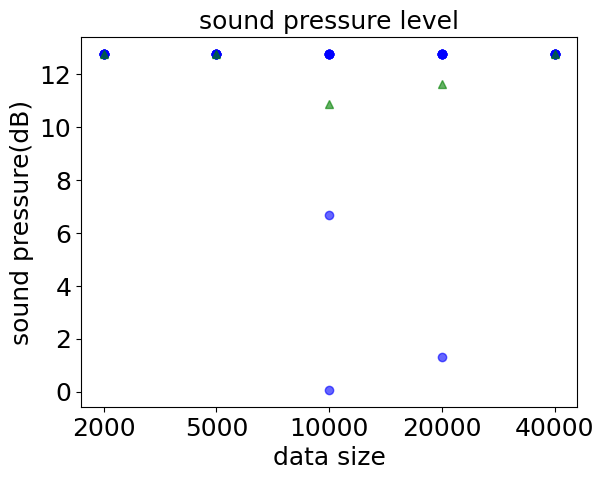

In [56]:
data_sizes = [2000, 5000, 10000, 20000, 40000]
results_scalar_mean = [ np.mean(np.array(results_scalar[i])) for i in data_sizes ]
results_scalar_array = [ np.array(results_scalar[i]) for i in data_sizes ]

# ax.set_xscale('log')
x_indices = np.arange(len(data_sizes))
for i, x_pos in enumerate(x_indices):
    y_values = results_scalar_array[i]
    y_values_mean = results_scalar_mean[i]
    x_values = [x_pos] * len(y_values)
    plt.scatter(x_values, y_values, alpha=0.6, color="blue")
plt.plot(x_indices, np.array(results_scalar_mean), alpha=0.6, color="green", marker="^", linestyle="")
plt.xticks(ticks=x_indices, labels=[str(i) for i in data_sizes])
plt.title("sound pressure level")
plt.xlabel("data size")
plt.ylabel("sound pressure(dB)")
plt.savefig('./sound_pressure_level/scatter/' + sound_name + '.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

torch.Size([1, 160000])
torch.Size([160000])
torch.Size([160000])
torch.Size([160000])
The primary nosie has 10 seconds !!!
1 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
3 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
4 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
5 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
6 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
7 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
8 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
9 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
10 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


/tmp/ipykernel_220278/1566350124.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  dis = np.array(dis)
/tmp/ipykernel_220278/1566350124.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  error = np.array(error)
/tmp/ipykernel_220278/1839205763.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org

0.0048679244 0.00183187
The primary nosie has 10 seconds !!!
1 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
3 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
4 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
5 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
6 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
7 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
8 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
9 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
10 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
0.0048679244 0.001025597
The primary nosie has 10 seconds !!!
1 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
2 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
3 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
4 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
5 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
6 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
7 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
8 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
9 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
10 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
0.0048679244 0.0008820321
The primary nosie has 10 seconds !!!
1 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
3 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
4 [0 1 0 0 0 0 0 0 0 0 0 0 0 0

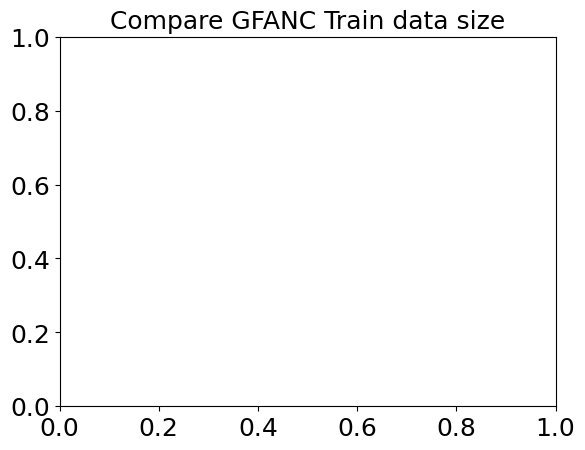

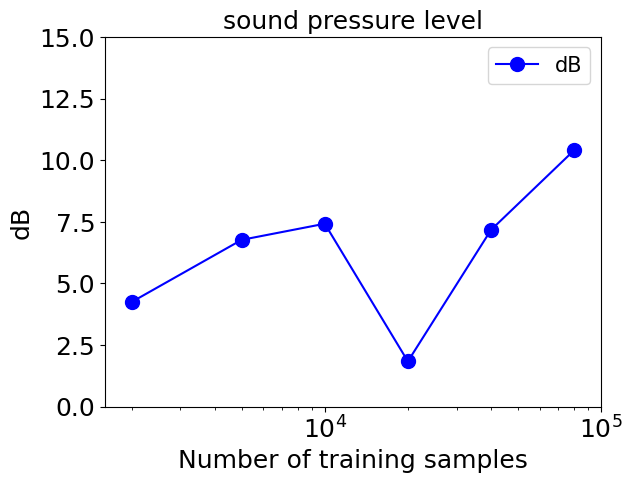

torch.Size([1, 160000])
torch.Size([160000])
torch.Size([160000])
torch.Size([160000])
The primary nosie has 10 seconds !!!
1 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
3 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
4 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
5 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
6 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
7 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
8 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
9 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
10 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
0.003523121 0.0034423629
The primary nosie has 10 seconds !!!
1 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
3 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
4 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
5 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
6 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
7 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
8 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
9 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
10 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
0.003523121 0.00082279433
The primary nosie has 10 seconds !!!
1 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
3

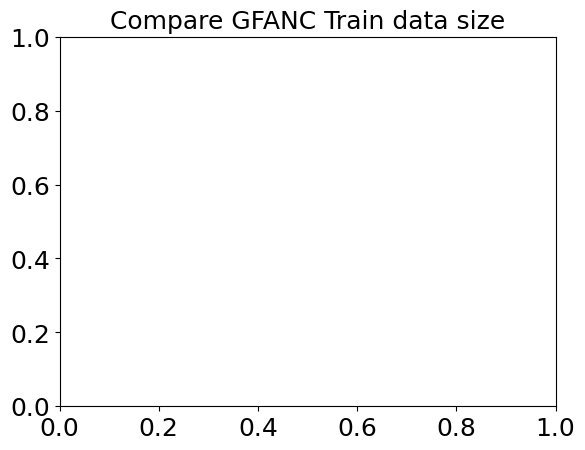

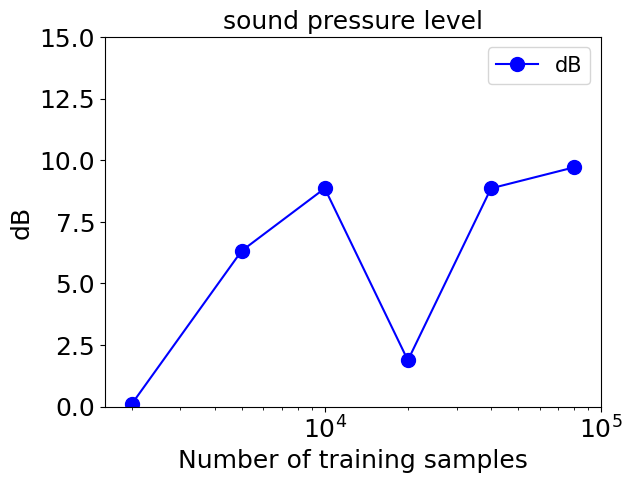

torch.Size([1, 160150])
torch.Size([160000])
torch.Size([160000])
torch.Size([160150])
The primary nosie has 10 seconds !!!
1 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
3 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
4 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
5 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
6 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
7 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
8 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
9 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
10 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
0.025384026 0.0024515553
The primary nosie has 10 seconds !!!
1 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
3 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
4 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
5 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
6 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
7 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
8 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
9 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
10 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
0.025384026 0.0024515553
The primary nosie has 10 seconds !!!
1 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
3 

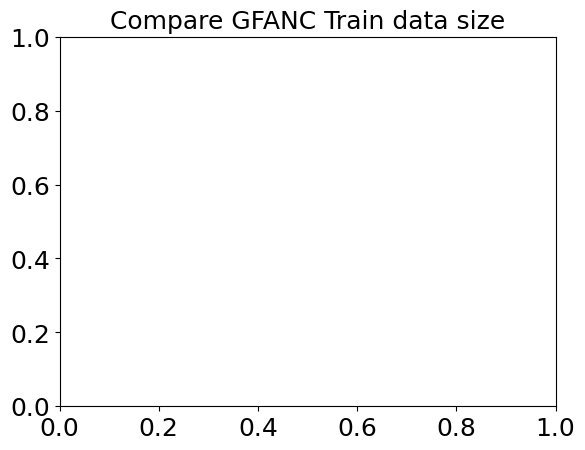

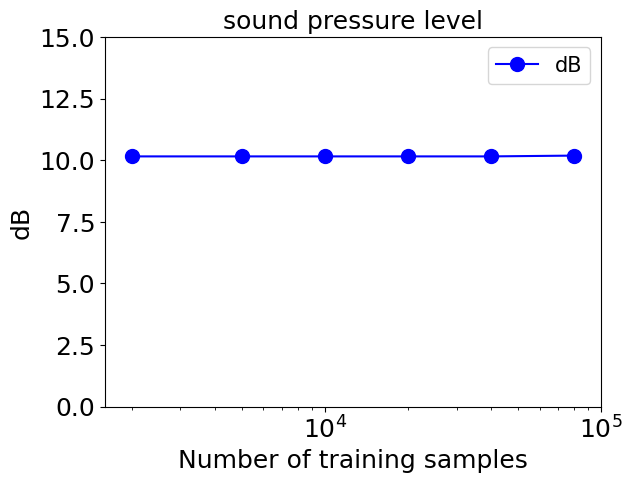

In [ ]:
# real noises
mdict = {}
fs = 16000
StepSize = 0.0001
import os
base_dir = "Real Noise Examples/"
files = ["Aircraft", "Helicopter", "Traffic"]
# names = ["A_Ⅱ_1_20250917", "B_Ⅱ_2_20251029", "B_Ⅱ_3_20251029"]
for file in files:
    y_max=15
    sound_name=file
    waveform, resample_rate = loading_real_wave_noise(folde_name=base_dir, sound_name=sound_name + ".wav")
    Pri_path, Secon_path = loading_paths_from_MAT(folder='Pz and Sz', subfolder='Dongyuan', Pri_path_file_name='Primary_path.mat', Sec_path_file_name='Secondary_path.mat')
    Dis, Fx, Re = Disturbance_generation_from_real_noise(fs=fs, Repet=0, wave_form=waveform, Pri_path=Pri_path, Sec_path=Secon_path)

    print(waveform.shape)
    print(Dis.shape)
    print(Fx.shape)
    print(Re.shape)

    import matplotlib as mpl
    mpl.rcParams['agg.path.chunksize'] = 10000
    Time = np.arange(len(Dis))*(1/fs)
    # GFANC: present frame to predict the next
    from gfanc.Control_filter_selection import General_Control_filter_selection
    BASE_MODEL_PTH = 'models_from_original_dataset/M6_res_Synthetic'
    path_mat = 'models/Pretrained_Sub_Control_filters.mat'
    data_sizes = [2000, 5000, 10000, 20000, 40000, ""]
    results = []
    results_scalar = []
    for i in data_sizes:
  
        # prediction index
        MODEL_PTH = BASE_MODEL_PTH + str(i) + ".pth"
        Filter_vector = Control_filter_selection(fs=16000, MODEL_PTH=MODEL_PTH, path_mat=path_mat, Primary_noise=Re.unsqueeze(0), threshold=0.5)

        Fixed_Cancellation = Fixed_filter_controller(Filter_vector=Filter_vector, fs=16000)
        ErrorGFANC = Fixed_Cancellation.noise_cancellation(Dis=Dis, Fx=Fx)

        level = sound_pressure_level_smoothed(Dis, ErrorGFANC )
        plt.title('Compare GFANC Train data size')
        if i == "":
            num = "80000"
        else:
            num = str(i)
        results.append([level, "train data size: " + num])
        results_scalar.append([sound_pressure_level(Dis, ErrorGFANC), "train data size: " + num])
    fig, ax = plt.subplots()
    ax.set_xscale('log')
    data_num = [2000, 5000, 10000, 20000, 40000, 80000]
    ax.plot(data_num, [i[0] for i in results_scalar], marker='o', markersize=10, color='b', label='dB')
    xmin = np.exp(np.log(80000)-np.log(100000)+np.log(2000))
    print
    ax.set_xlim(int(xmin), 100000)
    ax.set_ylim(0, y_max)
    ax.set_xlabel('Number of training samples')
    ax.set_ylabel('dB')
    ax.set_title('sound pressure level')
    ax.legend()
    plt.savefig('./sound_pressure_level/' + sound_name + '.png', dpi=600, bbox_inches='tight', pad_inches=0)
    plt.show()
# plt.figure(figsize=(10, 5))
# for result in results:
#     plt.plot(Time, result[0] , label=result[1])
# plt.ylabel('DB')
# plt.xlabel('Time (seconds)')
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
# plt.tight_layout()
# plt.grid()
# plt.savefig('SFANC_FxNLMS.pdf', dpi=600, bbox_inches='tight', pad_inches=0)
# plt.show()

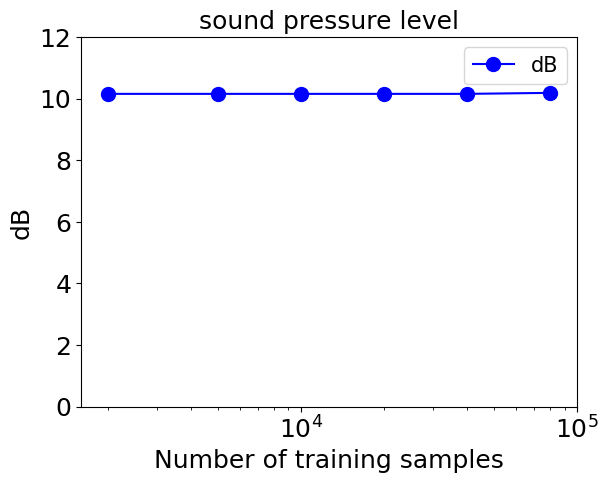

In [18]:
fig, ax = plt.subplots()
ax.set_xscale('log')
data_num = [2000, 5000, 10000, 20000, 40000, 80000]
ax.plot(data_num, [i[0] for i in results_scalar], marker='o', markersize=10, color='b', label='dB')
xmin = np.exp(np.log(80000)-np.log(100000)+np.log(2000))
print
ax.set_xlim(int(xmin), 100000)
ax.set_ylim(0, 12)
ax.set_xlabel('Number of training samples')
ax.set_ylabel('dB')
ax.set_title('sound pressure level')
ax.legend()
plt.savefig('./sound_pressure_level/' + sound_name + '.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

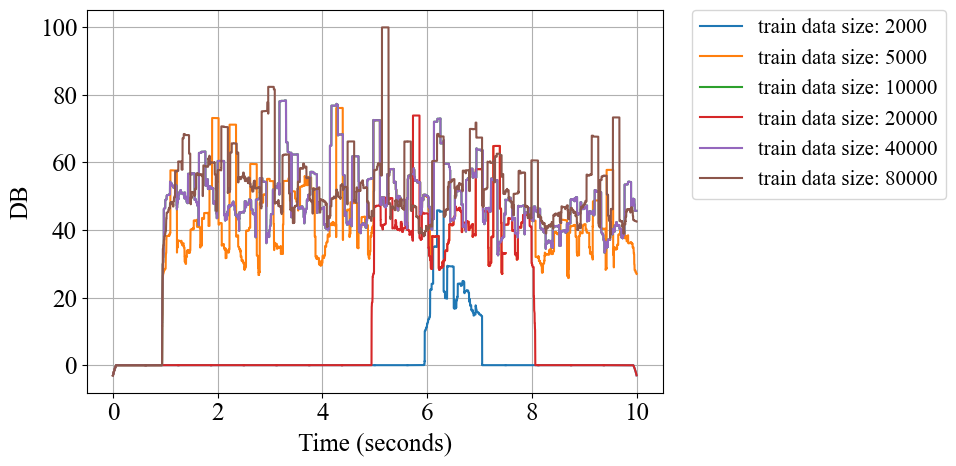

In [28]:
plt.figure(figsize=(10, 5))
for result in results:
    plt.plot(Time, result[0] , label=result[1])
plt.ylabel('DB')
plt.xlabel('Time (seconds)')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.grid()
plt.savefig('SFANC_FxNLMS.pdf', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

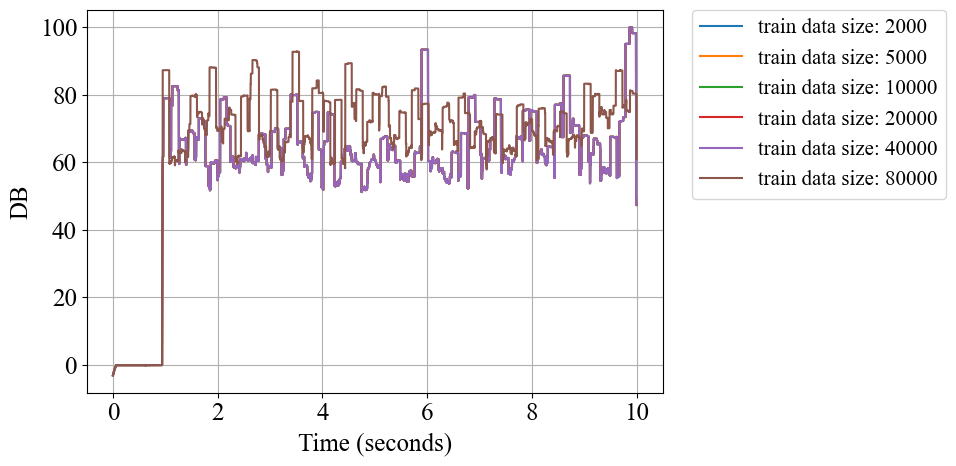

In [26]:
plt.figure(figsize=(10, 5))
for result in results:
    plt.plot(Time, result[0] , label=result[1])
plt.ylabel('DB')
plt.xlabel('Time (seconds)')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.grid()
plt.savefig('SFANC_FxNLMS.pdf', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

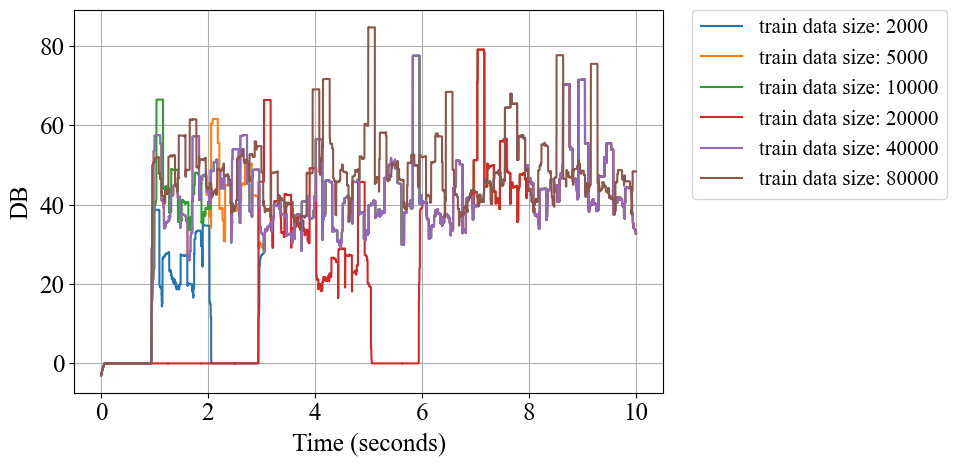

In [24]:
plt.figure(figsize=(10, 5))
for result in results:
    plt.plot(Time, result[0] , label=result[1])
plt.ylabel('DB')
plt.xlabel('Time (seconds)')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.grid()
plt.savefig('SFANC_FxNLMS.pdf', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

In [27]:
def plot_specgram(waveform, sample_rate, filepath, title="Spectrogram", xlim=None):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sample_rate

    figure, axes = plt.subplots(num_channels, 1)
    if num_channels == 1:
        axes = [axes]
    for c in range(num_channels):
        axes[c].specgram(waveform[c], Fs=sample_rate)
        if num_channels > 1:
            axes[c].set_ylabel(f'Channel {c+1}')
        if xlim:
            axes[c].set_xlim(xlim)
    figure.suptitle(title)
    plt.savefig(filepath)
    plt.close('all')

In [35]:
wave = torch.tensor(ErrorGFANC).unsqueeze(0)
plot_specgram(wave, fs, "spec")


/tmp/ipykernel_1920244/2591309485.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wave = torch.tensor(ErrorGFANC).unsqueeze(0)


In [76]:
# compare the Noise_Reduction_Level in every second

def Noise_Reduction_Level_Compute(Disturbance, Error):
    Power_dis = 10*np.log10(np.var(Disturbance))
    Power_err = 10*np.log10(np.var(Error))
    NR_level = Power_dis - Power_err
    return NR_level

if torch.is_tensor(Dis):
    Dis = Dis.numpy() # tensor to numpy
if torch.is_tensor(ErrorGFANC):
    ErrorGFANC = ErrorGFANC.numpy()

a, b, c = [], [], []
a.append(Dis[0])
b.append(Dis[0])
c.append(Dis[0])
Time1 = int(len(Dis)/fs)
for t in range(Time1):
    a.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], ErrorGFANC[t*fs:(t+1)*fs]))
    b.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], ErrorSFANC[t*fs:(t+1)*fs]))
    c.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], ErrorFxLMS[t*fs:(t+1)*fs]))
    
plt.title('(d) Averaged Noise Reduction Level of Every 1s')
plt.step(range(0,Time1+1), c, color='green', label='FxLMS')
plt.step(range(0,Time1+1), b, color='blue', label='SFANC')
plt.step(range(0,Time1+1), a, color='red', label='GFANC')
plt.ylabel('Noise Reduction Level (dB)')
plt.xlabel('Time (seconds)')
plt.xticks(range(0, Time1+1, 1)) # the interval in x
plt.legend()
plt.grid()
plt.savefig('Noise_Reduction_Level.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

NameError: name 'ErrorSFANC' is not defined